## Handwritten Digit Image classification Practice Dataset (MNIST)

In [9]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

In [2]:
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
print("Shape of training features : ", X_train.shape)
print("Shape of training labels : ", Y_train.shape)
print("Shape of testing features : ", X_test.shape)
print("Shape of testing labels : ", Y_test.shape)

Shape of training features :  (60000, 28, 28)
Shape of training labels :  (60000,)
Shape of testing features :  (10000, 28, 28)
Shape of testing labels :  (10000,)


In [ ]:
# The labels are of different classed , hence a multi-class classification problem
print(Y_train[:5])

[5 0 4 1 9]


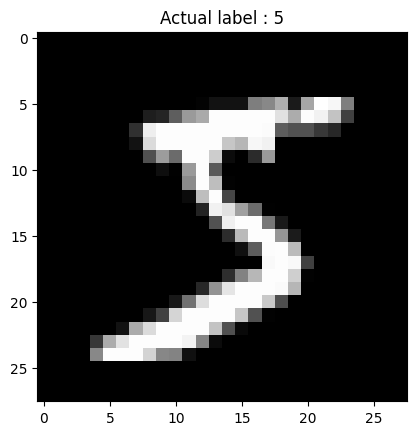

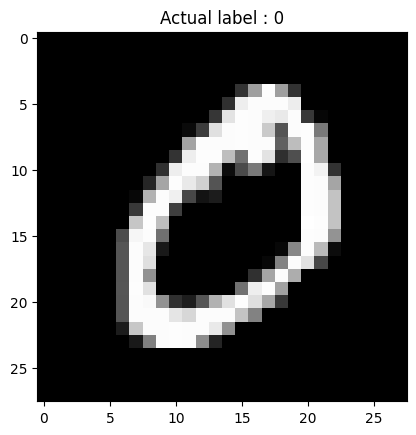

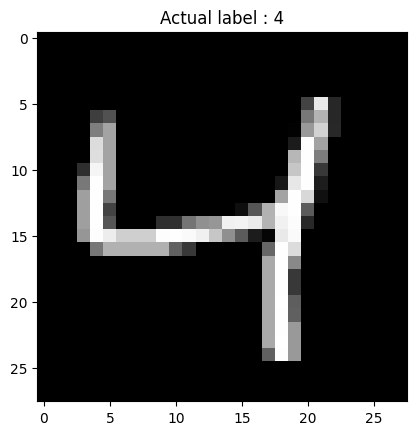

In [12]:
# Lets look at the images
for i in range(3):
    plt.title(f"Actual label : {Y_train[i]}") 
    plt.imshow(X_train[i], cmap="gray")
    plt.show()

In [13]:
# Normalizing pixels 
X_train = X_train / 255
X_test = X_test / 255

In [14]:
# Now lets build a model

model = Sequential()

model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))

d:\Deep Learning\Tensorflow\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="Adam")

In [17]:
model.fit(X_train, Y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2820 - val_loss: 0.1519
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1288 - val_loss: 0.1154
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0876 - val_loss: 0.1023
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0660 - val_loss: 0.0905
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0516 - val_loss: 0.0841
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0394 - val_loss: 0.0856
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0313 - val_loss: 0.0866
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0253 - val_loss: 0.0878
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0196 - val_loss: 0.0921
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0170 - val_loss: 0.1061


In [18]:
y_prob = model.predict(X_test)
print(y_prob[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step
[4.2468327e-09 4.4597992e-11 7.3439685e-07 2.7526054e-04 7.2638808e-14
 5.9264509e-09 6.3368472e-16 9.9971360e-01 7.0625474e-06 3.2957601e-06]


In [19]:
print(y_prob.shape)

(10000, 10)


In [20]:
y_pred = y_prob.argmax(axis=1)

In [22]:
# Lets compare the first 5 predictions
print("Actual labels : ", Y_test[:5])
print("Predicted labels : ", y_pred[:5])

Actual labels :  [7 2 1 0 4]
Predicted labels :  [7 2 1 0 4]


In [24]:
from sklearn.metrics import accuracy_score
print("Accuracy score of the model : ", accuracy_score(Y_test, y_pred) * 100)

Accuracy score of the model :  97.39999999999999
